# Cluster Checks

Load the 5km control grid and 500m selected sub-cells for inspection.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import pandas as pd

from src.utils.config_loader import load_config, get_data_dir
from src.data_processing.load_boundaries import (
    load_control_grid,
    load_selected_subcells,
    validate_crs,
)

config = load_config()
data_dir = get_data_dir(config)
print('data_dir:', data_dir)

Loaded local config overrides from config.local.yaml
data_dir: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\1_Baseline\0.4_listing_geospatial


In [2]:
# 5km control grid (sampled + replacement + dropped_sparse)
grid_5km = load_control_grid(data_dir)
grid_5km = validate_crs(grid_5km)

print(f'Rows: {len(grid_5km)}')
print(f'CRS:  {grid_5km.crs}')
print(f'\nsample_status counts:')
print(grid_5km['sample_status'].value_counts())
print(f'\nColumns: {list(grid_5km.columns)}')
grid_5km.head()

Loaded 48 control grid cells from G:\Shared drives\TZ-CCT_RUBEV-0825\Data\1_Baseline\0.4_listing_geospatial\01_input_data\boundaries\control_grid_5km_flagged.gpkg
Reprojecting from EPSG:32736 to EPSG:4326
Rows: 48
CRS:  EPSG:4326

sample_status counts:
sample_status
sampled           33
dropped_sparse    10
replacement        5
Name: count, dtype: int64

Columns: ['id', 'left', 'top', 'right', 'bottom', 'row_index', 'col_index', 'id5km', 'sample_status', 'geometry']


,id,left,top,right,bottom,row_index,col_index,id5km,sample_status,geometry
0,10578,838536.9001,9.172550e+06,843536.9001,9.167550e+06,89,57,10578,dropped_sparse,"MULTIPOLYGON (((36.11137 -7.49537, 36.11221 -7..."
1,10758,843536.9001,9.192550e+06,848536.9001,9.187550e+06,85,58,10758,sampled,"MULTIPOLYGON (((36.11081 -7.29414, 36.15604 -7..."
2,10759,843536.9001,9.187550e+06,848536.9001,9.182550e+06,86,58,10759,dropped_sparse,"MULTIPOLYGON (((36.11112 -7.3393, 36.15636 -7...."
3,10760,843536.9001,9.182550e+06,848536.9001,9.177550e+06,87,58,10760,replacement,"MULTIPOLYGON (((36.11144 -7.38446, 36.15668 -7..."
4,10761,843536.9001,9.177550e+06,848536.9001,9.172550e+06,88,58,10761,replacement,"MULTIPOLYGON (((36.11175 -7.42962, 36.157 -7.4..."


In [3]:
# 500m selected sub-cells
subcells = load_selected_subcells(data_dir)
subcells = validate_crs(subcells)

print(f'Rows: {len(subcells)}')
print(f'CRS:  {subcells.crs}')
print(f'\nsample_status counts:')
print(subcells['sample_status'].value_counts())
print(f'\nselection_role counts:')
print(subcells['selection_role'].value_counts())
print(f'\nColumns: {list(subcells.columns)}')
subcells.head()

Loaded 110 selected sub-cells from G:\Shared drives\TZ-CCT_RUBEV-0825\Data\1_Baseline\0.4_listing_geospatial\01_input_data\boundaries\selected_subcells_500m.gpkg
Reprojecting from EPSG:32736 to EPSG:4326
Rows: 110
CRS:  EPSG:4326

sample_status counts:
sample_status
sampled        97
replacement    13
Name: count, dtype: int64

selection_role counts:
selection_role
primary    68
reserve    42
Name: count, dtype: int64

Columns: ['grid_id', 'col', 'row', 'cell_size', 'ward_name', 'district', 'region', 'is_treatme', 'is_program', 'is_adjacen', '5km_id', 'building_count', 'mean_confidence', 'selection_role', 'sample_status', 'centroid_x', 'centroid_y', 'latitude', 'longitude', 'geometry']


,grid_id,col,row,cell_size,ward_name,district,region,is_treatme,is_program,is_adjacen,5km_id,building_count,mean_confidence,selection_role,sample_status,centroid_x,centroid_y,latitude,longitude,geometry
0,G_0588_0987,588,987,500,Rudewa,Kilosa,Morogoro,False,True,False,10758.0,45,0.774017,primary,sampled,847786.900139,9.191300e+06,-7.305162,36.149334,"MULTIPOLYGON (((36.14709 -7.30744, 36.14706 -7..."
1,G_0587_0987,587,987,500,Chanzuru,Kilosa,Morogoro,False,True,False,10758.0,92,0.780214,primary,sampled,847286.900139,9.191300e+06,-7.305194,36.144811,"MULTIPOLYGON (((36.14256 -7.30747, 36.14253 -7..."
2,G_0586_0964,586,964,500,Kilangali,Kilosa,Morogoro,False,True,False,10760.0,25,0.762718,primary,replacement,846786.900139,9.179800e+06,-7.409095,36.141019,"MULTIPOLYGON (((36.13877 -7.41137, 36.13874 -7..."
3,G_0586_0965,586,965,500,Kilangali,Kilosa,Morogoro,False,True,False,10760.0,22,0.762933,primary,replacement,846786.900139,9.180300e+06,-7.404579,36.140987,"MULTIPOLYGON (((36.13874 -7.40685, 36.13871 -7..."
4,G_0587_0964,587,964,500,Tindiga,Kilosa,Morogoro,False,True,False,10760.0,27,0.752169,reserve,replacement,847286.900139,9.179800e+06,-7.409063,36.145543,"MULTIPOLYGON (((36.1433 -7.41134, 36.14326 -7...."


## Overlap check: client-flagged implementation areas

Load the client's flagged pixels and check which of our selected 500m sub-cells overlap spatially.

In [4]:
# Load client-flagged areas
flagged_path = Path(r"G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\grid_info\_temp\Sampled_control_pixels.gpkg")
flagged = gpd.read_file(flagged_path)

print(f'Rows:    {len(flagged)}')
print(f'CRS:     {flagged.crs}')
print(f'Columns: {list(flagged.columns)}')
print(f'\nVCSL_village value counts:')
print(flagged['VCSL_village'].value_counts(dropna=False))
flagged.head()

Rows:    905
CRS:     EPSG:32736
Columns: ['id', 'left_', 'top', 'right_', 'bottom', 'row_index', 'col_index', 'id5km', 'Control_pixel_sampled', 'Control_pixel_replacement_sampl', 'VCSL_village', 'geometry']

VCSL_village value counts:
VCSL_village
None             610
Mikumi            50
Madudumizi        22
Mgogozi           20
Malolo B          18
Lumbiji           16
Malolo A          16
Mhenda            15
Munisagara        12
Kisanga           11
Chonwe            11
Madizini          11
Mhowe              9
Dodoma Isanga      6
Ibingu             6
Ulaya Mbuyuni      6
Udung`hu           6
Mbamba             6
Mvumi              6
Ilonga             5
Msimba             5
Msowero            5
Ilakala            4
Kisongwe           4
Mamboya            3
Chabima            3
Kikundi            3
Rudewa Batini      3
Ulaya Kibaoni      3
Doma               3
Gongoni            2
Kigunga            2
Ihombwe            1
Nyali              1
Makwambe           1
Name: count, dty

,id,left_,top,right_,bottom,row_index,col_index,id5km,Control_pixel_sampled,Control_pixel_replacement_sampl,VCSL_village,geometry
0,9821,818536.9001,9.277550e+06,823536.9001,9.272550e+06,68,53,9821,NaN,NaN,None,"MULTIPOLYGON (((822369.204 9274626.685, 821616..."
1,9822,818536.9001,9.272550e+06,823536.9001,9.267550e+06,69,53,9822,NaN,NaN,None,"MULTIPOLYGON (((821616.326 9272549.999, 819803..."
2,9823,818536.9001,9.267550e+06,823536.9001,9.262550e+06,70,53,9823,NaN,NaN,None,"MULTIPOLYGON (((819279.233 9266103.529, 819121..."
3,9824,818536.9001,9.262550e+06,823536.9001,9.257550e+06,71,53,9824,NaN,NaN,None,"MULTIPOLYGON (((819121.211 9262549.999, 818898..."
4,9825,818536.9001,9.257550e+06,823536.9001,9.252550e+06,72,53,9825,NaN,NaN,None,"MULTIPOLYGON (((818876.477 9257046.494, 820067..."


In [5]:
# Filter to only VCSL villages (not None)
flagged_vcsl = flagged[flagged['VCSL_village'].notna()].copy()
print(f'Flagged pixels with a VCSL village: {len(flagged_vcsl)}')
print(f'Flagged pixels without (None):      {len(flagged) - len(flagged_vcsl)}')

# Ensure both layers are in the same CRS before spatial operations
if flagged_vcsl.crs != subcells.crs:
    flagged_vcsl = flagged_vcsl.to_crs(subcells.crs)
    print(f'\nReprojected flagged areas to {subcells.crs}')

# Spatial join: find sub-cells that intersect any VCSL-flagged area
overlapping = gpd.sjoin(subcells, flagged_vcsl, how='inner', predicate='intersects')

# De-duplicate (one sub-cell can overlap multiple flagged polygons)
overlap_ids = overlapping.index.unique()
subcells_overlap = subcells.loc[overlap_ids].copy()

# Also capture which VCSL villages each sub-cell touches
vcsl_per_subcell = (
    overlapping.groupby(overlapping.index)['VCSL_village']
    .apply(lambda x: ', '.join(sorted(x.unique())))
)
subcells_overlap['overlapping_vcsl_villages'] = vcsl_per_subcell

print(f'\nTotal 500m sub-cells:              {len(subcells)}')
print(f'Overlapping VCSL flagged areas:     {len(subcells_overlap)}')
print(f'Non-overlapping:                    {len(subcells) - len(subcells_overlap)}')

if len(subcells_overlap) > 0:
    print(f'\n--- Overlapping sub-cells ---')
    cols = [c for c in ['5km_id', 'grid_id', 'ward_name', 'selection_role',
                         'sample_status', 'building_count', 'overlapping_vcsl_villages']
            if c in subcells_overlap.columns]
    display(subcells_overlap[cols])
else:
    print('\nNo overlap found.')

Flagged pixels with a VCSL village: 295
Flagged pixels without (None):      610

Reprojected flagged areas to EPSG:4326

Total 500m sub-cells:              110
Overlapping VCSL flagged areas:     24
Non-overlapping:                    86

--- Overlapping sub-cells ---


,5km_id,grid_id,ward_name,selection_role,sample_status,building_count,overlapping_vcsl_villages
33,12418.0,G_0670_0941,Mlembwe,primary,sampled,407,Malolo B
34,12418.0,G_0670_0940,Mlembwe,primary,sampled,205,Malolo B
35,12418.0,G_0670_0942,Mlembwe,reserve,sampled,183,Malolo B
36,12418.0,G_0670_0943,Mlembwe,reserve,sampled,23,Malolo B
42,13150.0,G_0718_0980,Mkutano,primary,sampled,61,Malolo A
43,13151.0,G_0718_0976,Mkutano,primary,sampled,301,Malolo A
44,13151.0,G_0717_0977,Lilombe,primary,sampled,362,Malolo A
45,13151.0,G_0718_0977,Mkutano,reserve,sampled,134,Malolo A
46,13151.0,G_0717_0978,Lilombe,reserve,sampled,33,Malolo A
91,13869.0,G_0758_1158,Mkutano,primary,replacement,21,Lumbiji


In [6]:
# Map: full 5km study area grid + treatment villages + VCSL areas + sampled sub-cells + overlaps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as cx

from src.data_processing.load_boundaries import load_study_area_grid

# Load the full study area grid (all 905 5km cells)
full_grid = load_study_area_grid(data_dir)
full_grid = validate_crs(full_grid)

# Load the actual treatment village polygons
villages_path = data_dir / "01_input_data" / "boundaries" / "Sampled_villages.shp"
villages = gpd.read_file(villages_path)
villages = validate_crs(villages)
print(f'Treatment village polygons: {len(villages)}')

Loaded 905 grid cells from G:\Shared drives\TZ-CCT_RUBEV-0825\Data\1_Baseline\0.4_listing_geospatial\01_input_data\boundaries\Area_study_5km_grid.gpkg
Reprojecting from EPSG:32736 to EPSG:4326
Treatment village polygons: 43


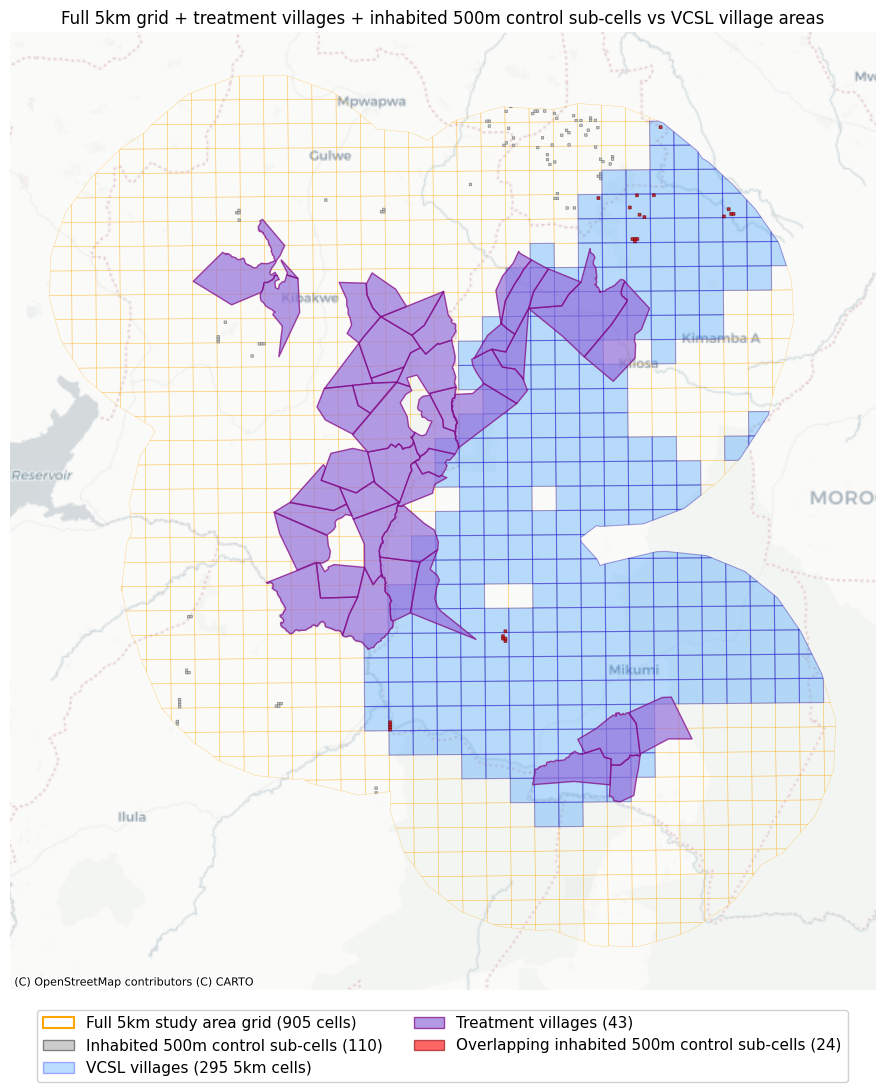

In [7]:
# Reproject everything to Web Mercator once
full_grid_wm = full_grid.to_crs(epsg=3857)
villages_wm = villages.to_crs(epsg=3857)
subcells_wm = subcells.to_crs(epsg=3857)
flagged_vcsl_wm = flagged_vcsl.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 11))

# 1. Full 5km study area grid — outline only, light orange (back layer)
full_grid_wm.plot(ax=ax, facecolor='none', edgecolor='orange', linewidth=0.3, alpha=0.5)

# 2. Inhabited 500m control sub-cells in light grey
subcells_wm.plot(ax=ax, facecolor='#cccccc', edgecolor='grey', linewidth=0.5)

# 3. VCSL-flagged 5km cells in semi-transparent blue
flagged_vcsl_wm.plot(ax=ax, facecolor='dodgerblue', edgecolor='blue', alpha=0.3, linewidth=0.8)

# 4. Treatment village polygons — solid purple
villages_wm.plot(ax=ax, facecolor='mediumpurple', edgecolor='purple', alpha=0.7, linewidth=1.0)

# 5. Overlapping inhabited 500m control sub-cells in red (top layer)
n_overlap = len(subcells_overlap)
if n_overlap > 0:
    subcells_overlap_wm = subcells_overlap.to_crs(epsg=3857)
    subcells_overlap_wm.plot(ax=ax, facecolor='red', edgecolor='darkred', alpha=0.6, linewidth=1)

# Zoom to the full grid extent with some padding
combined_bounds = full_grid_wm.total_bounds
dx = (combined_bounds[2] - combined_bounds[0]) * 0.05
dy = (combined_bounds[3] - combined_bounds[1]) * 0.05
ax.set_xlim(combined_bounds[0] - dx, combined_bounds[2] + dx)
ax.set_ylim(combined_bounds[1] - dy, combined_bounds[3] + dy)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom='auto')

# Explicit legend patches — placed below the axes
legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor='orange', linewidth=1.5,
                   label=f'Full 5km study area grid ({len(full_grid)} cells)'),
    mpatches.Patch(facecolor='#cccccc', edgecolor='grey',
                   label=f'Inhabited 500m control sub-cells ({len(subcells)})'),
    mpatches.Patch(facecolor='dodgerblue', edgecolor='blue', alpha=0.3,
                   label=f'VCSL villages ({len(flagged_vcsl)} 5km cells)'),
    mpatches.Patch(facecolor='mediumpurple', edgecolor='purple', alpha=0.7,
                   label=f'Treatment villages ({len(villages)})'),
]
if n_overlap > 0:
    legend_handles.append(
        mpatches.Patch(facecolor='red', edgecolor='darkred', alpha=0.6,
                       label=f'Overlapping inhabited 500m control sub-cells ({n_overlap})')
    )
ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=11,
    framealpha=0.9,
    borderaxespad=0.0,
)

ax.set_title('Full 5km grid + treatment villages + inhabited 500m control sub-cells vs VCSL village areas',
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()